# Robustez y comparación estadística

Secciones 5.4 y 6 de la guía. Con 140 modelos hay 9,730 pares posibles: probarlos todos con α = 0.05
produciría unos 487 falsos positivos solo por azar. La comparación sigue por eso una **secuencia
jerárquica**:

* **Clasificación:** Friedman (¿algún modelo difiere?) → Nemenyi y diagrama de Diferencia Crítica
  (¿cuáles?) → DeLong sobre un subconjunto reducido y justificado, con ajuste de Holm y
  Benjamini-Hochberg → tamaño del efecto (delta de Cliff) e intervalos bootstrap BCa.
* **Regresión:** Model Confidence Set sobre el universo de 28 modelos → Giacomini-White o Clark-West
  entre los finalistas según haya anidamiento → Diebold-Mariano con corrección HLN como confirmación
  puntual, con intervalo por bootstrap estacionario → tamaño del efecto (d de Cohen), y como control
  de *data snooping* el SPA de Hansen, el Reality Check de White y el StepM de Romano y Wolf frente
  al mejor modelo lineal.
* **Evaluación general:** los 14 algoritmos comparados en la misma métrica (AUC-ROC sobre `TARGET`).

In [1]:
# --- preambulo comun: localiza la raiz del libro y carga el paquete src ------
import os, sys, warnings
from pathlib import Path
RAIZ = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / "_config.yml").is_file() and (p / "src").is_dir())
if str(RAIZ) not in sys.path:
    sys.path.insert(0, str(RAIZ))
# los procesos paralelos de joblib (loky) tambien deben encontrar `src`
os.environ["PYTHONPATH"] = str(RAIZ) + os.pathsep + os.environ.get("PYTHONPATH", "")
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message="IProgress not found")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from src import config, graficos
config.fijar_semillas()
config.crear_directorios()
graficos.estilo()
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)
print(config.resumen())

Raiz del proyecto     : entregable3
Modo prueba           : False
Semilla               : 42
CV anidada            : 5 externos x 3 internos
Evaluaciones/optimiz. : 20
Nucleos               : 11   paralelo interno: True
XGBoost               : device='cuda'
Random Forest         : xgbrf   KNN: torch


In [2]:
import json, itertools
from sklearn.metrics import roc_auc_score
from src import experimento as ex, finales as fin, estadistica as est_, datos, metricas as met

pliegues, maestra = ex.consolidar()
conj = datos.cargar_traspaso()
DIR_EST = config.DIR_ESTUDIOS / "estadistica"
DIR_EST.mkdir(parents=True, exist_ok=True)
N_BOOT = 200 if config.MODO_PRUEBA else 2000
fc = fin.seleccionar_finalistas(maestra, "clasificacion")
fr = fin.seleccionar_finalistas(maestra, "regresion")
FC, FR = fin.cargar_finales("clasificacion"), fin.cargar_finales("regresion")
completas = maestra[maestra["pliegues"] == config.N_EXTERNOS]

## 1. Robustez y estabilidad de las métricas (Sección 5.4)

### 1.1 Media ± desviación estándar a través de los pliegues externos

La tabla completa de las 140 combinaciones está en `resultados/tabla_maestra.csv`; aquí, las 15
mejores de cada tarea.

In [3]:
def formato(df, cols):
    out = df[["modelo", "balanceo", "optimizador"]].copy()
    for c in cols:
        out[c] = [f"{m:.4f} ± {s:.4f}" for m, s in zip(df[f"m_{c}_media"], df[f"m_{c}_sd"])]
    return out
for tarea, cols in (("clasificacion", ["auc_roc", "recall", "f1"]), ("regresion", ["auc_roc", "rmse", "mae"])):
    t = completas[completas["tarea"] == tarea].sort_values("m_auc_roc_media", ascending=False)
    print(f"== {tarea}: {len(t)} combinaciones completas ==")
    display(formato(t.head(15), cols).style.hide(axis="index"))

== clasificacion: 112 combinaciones completas ==


modelo,balanceo,optimizador,auc_roc,recall,f1
xgboost,ninguno,genetica,0.7721 ± 0.0038,0.6591 ± 0.0197,0.2863 ± 0.0020
xgboost,ninguno,rejilla,0.7720 ± 0.0035,0.6736 ± 0.0100,0.2844 ± 0.0040
xgboost,ninguno,aleatoria,0.7717 ± 0.0035,0.6765 ± 0.0248,0.2810 ± 0.0063
xgboost,smote,bayesiana,0.7713 ± 0.0039,0.6594 ± 0.0108,0.2850 ± 0.0032
xgboost,adasyn,aleatoria,0.7712 ± 0.0027,0.6724 ± 0.0219,0.2832 ± 0.0036
xgboost,smote,genetica,0.7710 ± 0.0036,0.6633 ± 0.0175,0.2847 ± 0.0046
xgboost,ninguno,bayesiana,0.7710 ± 0.0038,0.6633 ± 0.0084,0.2843 ± 0.0043
xgboost,class_weight,bayesiana,0.7709 ± 0.0038,0.6781 ± 0.0183,0.2823 ± 0.0034
xgboost,class_weight,aleatoria,0.7708 ± 0.0034,0.6725 ± 0.0109,0.2822 ± 0.0059
xgboost,smote,aleatoria,0.7708 ± 0.0037,0.6662 ± 0.0210,0.2833 ± 0.0050


== regresion: 28 combinaciones completas ==


modelo,balanceo,optimizador,auc_roc,rmse,mae
xgboost,ninguno,bayesiana,0.7695 ± 0.0032,0.2596 ± 0.0003,0.1366 ± 0.0005
xgboost,ninguno,aleatoria,0.7692 ± 0.0027,0.2597 ± 0.0004,0.1370 ± 0.0012
xgboost,ninguno,rejilla,0.7686 ± 0.0031,0.2595 ± 0.0003,0.1361 ± 0.0003
xgboost,ninguno,genetica,0.7680 ± 0.0031,0.2598 ± 0.0003,0.1370 ± 0.0004
lasso,ninguno,aleatoria,0.7554 ± 0.0026,0.2628 ± 0.0002,0.1448 ± 0.0003
lasso,ninguno,rejilla,0.7553 ± 0.0025,0.2628 ± 0.0002,0.1447 ± 0.0004
lasso,ninguno,bayesiana,0.7553 ± 0.0025,0.2628 ± 0.0002,0.1447 ± 0.0003
lasso,ninguno,genetica,0.7553 ± 0.0025,0.2629 ± 0.0002,0.1447 ± 0.0004
ridge,ninguno,bayesiana,0.7549 ± 0.0026,0.2629 ± 0.0003,0.1451 ± 0.0003
ridge,ninguno,rejilla,0.7548 ± 0.0025,0.2629 ± 0.0002,0.1449 ± 0.0004


### 1.2 Sensibilidad a la semilla

Cada modelo final con aleatoriedad interna (bosques, XGBoost, PCA aleatorizado de KNN, Nystroem,
selección aleatoria de variables del árbol, SMOTE/ADASYN) se reentrena con tres semillas adicionales
y se mide su AUC en prueba. La pregunta es si las diferencias entre modelos son mayores que la
variabilidad intrínseca de cada uno: se compara la desviación entre semillas con la desviación entre
pliegues y con la distancia al siguiente modelo del ranking.

In [4]:
def tiene_azar(r):
    return (r["modelo"] in ("random_forest", "xgboost", "knn", "arbol")
            or r["balanceo"] in ("smote", "adasyn")
            or (r["modelo"] in ("svm", "svr") and r["params"].get("nucleo") == "rbf_nystroem"))
filas = []
for tarea, F in (("clasificacion", FC), ("regresion", FR)):
    orden = sorted(F, key=lambda m: -F[m]["registro"]["auc_cv_media"])
    for i, m in enumerate(orden):
        r = F[m]["registro"]
        fila = {"tarea": tarea, "modelo": m, "auc_prueba_semilla_42": r["metricas"]["auc_roc"],
                "sd_pliegues_cv": r["auc_cv_sd"],
                "distancia_al_siguiente_cv": (r["auc_cv_media"] - F[orden[i + 1]]["registro"]["auc_cv_media"]
                                              if i + 1 < len(orden) else np.nan)}
        if tiene_azar(r):
            s = fin.sensibilidad_semillas(conj, tarea, m, semillas=(0, 1, 2), verboso=True)
            if len(s):
                todas = np.r_[s["auc_roc"].to_numpy(), r["metricas"]["auc_roc"]]
                fila.update({"semillas": len(todas), "auc_media_semillas": todas.mean(),
                             "sd_semillas": todas.std(ddof=1), "rango_semillas": np.ptp(todas)})
        filas.append(fila)
semillas_df = pd.DataFrame(filas)
semillas_df.to_csv(DIR_EST / "sensibilidad_semillas.csv", index=False)
display(semillas_df.style.format(precision=4, na_rep="-").hide(axis="index"))

tarea,modelo,auc_prueba_semilla_42,sd_pliegues_cv,distancia_al_siguiente_cv,semillas,auc_media_semillas,sd_semillas,rango_semillas
clasificacion,xgboost,0.7754,0.0038,0.0143,4.0000,0.7752,0.0005,0.0011
clasificacion,svm,0.7595,0.0031,0.0003,4.0000,0.7598,0.0004,0.0010
clasificacion,logistica,0.7597,0.0028,0.0079,-,-,-,-
clasificacion,random_forest,0.7544,0.0035,0.0532,4.0000,0.7550,0.0007,0.0016
clasificacion,arbol,0.7017,0.0060,0.0078,4.0000,0.7017,0.0000,0.0000
clasificacion,knn,0.6975,0.0013,0.0423,4.0000,0.6974,0.0005,0.0011
clasificacion,naive_bayes,0.6477,0.0019,-,-,-,-,-
regresion,xgboost,0.7737,0.0032,0.0141,4.0000,0.7740,0.0004,0.0008
regresion,lasso,0.7604,0.0026,0.0005,-,-,-,-
regresion,ridge,0.7594,0.0026,0.0073,-,-,-,-


**Lectura.** La variabilidad por la semilla es pequeña frente a la que introduce la partición. En
todos los modelos con componentes aleatorios, la desviación entre las 4 semillas (0.0000-0.0007) es
entre 2.6 y 12 veces menor que la desviación entre pliegues externos (0.0013-0.0060); la excepción es
SVR (0.0031 frente a 0.0034), cuya inestabilidad ya mostró el capítulo 03. El árbol seleccionado da
el mismo AUC con todas las semillas: su configuración no tiene un componente aleatorio efectivo.

Las distancias entre modelos consecutivos del ranking separan dos situaciones. XGBoost aventaja al
segundo por 0.0143 en clasificación y 0.0141 en regresión, entre 4 y 29 veces ambas desviaciones, y
Random Forest y KNN también están lejos de sus siguientes (0.03-0.05). Pero SVM y la logística están
a 0.0003 y Lasso y Ridge a 0.0005: distancias por debajo de la desviación entre pliegues e incluso de
la de semillas, que no permiten ordenarlos sin una prueba formal. Esa es la motivación de la sección
2.

## 2. Bloques para las pruebas de medidas repetidas

Friedman y Nemenyi requieren medir todos los modelos sobre los mismos bloques. Los 5 pliegues externos
son pocos bloques para 112 modelos (la diferencia crítica de Nemenyi sería enorme). Como cada modelo
tiene predicciones fuera de muestra para **las mismas 246 mil observaciones**, cada pliegue externo se
divide en 10 sub-bloques estratificados de ~4,900 observaciones (~400 positivos): 50 bloques disjuntos,
idénticos para todos los modelos, sobre los que se calcula el AUC. Los sub-bloques de un mismo pliegue
comparten los modelos entrenados, de modo que no son del todo independientes; la inferencia es algo
liberal y se complementa con las pruebas sobre la prueba final.

In [5]:
N_SUB = 10
def asignar_bloques(ref):
    rng = np.random.default_rng(config.SEMILLA)
    sub = np.empty(len(ref), dtype=int)
    for k in range(config.N_EXTERNOS):
        for c in (0, 1):
            idx = np.where((ref["pliegue"].to_numpy() == k) & (ref["y"].to_numpy() == c))[0]
            rng.shuffle(idx)
            sub[idx] = np.arange(len(idx)) % N_SUB
    return ref["pliegue"].to_numpy() * N_SUB + sub

def nombre_combo(tarea, m, b, o):
    return f"{m}|{b}|{o}" if tarea == "clasificacion" else f"{m}|{o}"

def matriz_bloques(tarea, combos, metrica="auc"):
    ruta = DIR_EST / f"bloques_{tarea}_{metrica}_{len(combos)}.csv"
    if ruta.is_file():
        return pd.read_csv(ruta)
    ref = ex.predicciones_oof(tarea, *combos[0])
    bloque = asignar_bloques(ref)
    out = {}
    for c in combos:
        o = ex.predicciones_oof(tarea, *c)
        assert np.array_equal(o["fila"].to_numpy(), ref["fila"].to_numpy())
        y, s = o["y"].to_numpy(), o["s"].to_numpy()
        if metrica == "auc":
            out[nombre_combo(tarea, *c)] = [roc_auc_score(y[bloque == b], s[bloque == b])
                                            for b in range(config.N_EXTERNOS * N_SUB)]
        else:
            out[nombre_combo(tarea, *c)] = [np.mean((y[bloque == b] - s[bloque == b]) ** 2)
                                            for b in range(config.N_EXTERNOS * N_SUB)]
    df = pd.DataFrame(out)
    df.to_csv(ruta, index=False)
    return df

combos_clf = [tuple(r) for r in completas[completas["tarea"] == "clasificacion"][["modelo", "balanceo", "optimizador"]].to_numpy()]
combos_reg = [tuple(r) for r in completas[completas["tarea"] == "regresion"][["modelo", "balanceo", "optimizador"]].to_numpy()]
B_clf = matriz_bloques("clasificacion", combos_clf)
B_reg = matriz_bloques("regresion", combos_reg)
print(f"Clasificación: {B_clf.shape[0]} bloques x {B_clf.shape[1]} modelos | "
      f"Regresión: {B_reg.shape[0]} bloques x {B_reg.shape[1]} modelos")

Clasificación: 50 bloques x 112 modelos | Regresión: 50 bloques x 28 modelos


## 3. Clasificación

### 3.1 Etapa 1: prueba ómnibus de Friedman

In [6]:
fr_todos = est_.friedman(B_clf)
fam_clf = [tuple(r) for r in fc[["modelo", "balanceo", "optimizador"]].to_numpy()]
B_fam = B_clf[[nombre_combo("clasificacion", *c) for c in fam_clf]]
B_fam.columns = [c[0] for c in fam_clf]
fr_fam = est_.friedman(B_fam)
omnibus = pd.DataFrame([
    {"Conjunto": f"las {fr_todos['modelos']} combinaciones", "chi2_F": fr_todos["chi2"], "g.l.": fr_todos["gl"],
     "p": fr_todos["p"], "F Iman-Davenport": fr_todos["F_iman_davenport"], "p_F": fr_todos["p_F"]},
    {"Conjunto": "los 7 modelos (mejor combinación de cada uno)", "chi2_F": fr_fam["chi2"], "g.l.": fr_fam["gl"],
     "p": fr_fam["p"], "F Iman-Davenport": fr_fam["F_iman_davenport"], "p_F": fr_fam["p_F"]}])
omnibus["Conclusión"] = np.where(omnibus["p"] < 0.05, "Se rechaza H0: existen diferencias",
                                 "No se rechaza H0")
display(omnibus.style.format({"chi2_F": "{:.2f}", "p": "{:.3g}", "F Iman-Davenport": "{:.2f}",
                              "p_F": "{:.3g}"}).hide(axis="index"))

Conjunto,chi2_F,g.l.,p,F Iman-Davenport,p_F,Conclusión
las 112 combinaciones,5377.71,111,0,1529.46,0,Se rechaza H0: existen diferencias
los 7 modelos (mejor combinación de cada uno),280.25,6,1.39e-57,695.36,1.95e-170,Se rechaza H0: existen diferencias


### 3.2 Etapa 2: Nemenyi y diagrama de Diferencia Crítica

Se muestran dos diagramas: los 7 algoritmos (mejor combinación de cada uno) y las 15 mejores
combinaciones del estudio. Los modelos unidos por una barra roja no difieren significativamente
(α = 0.05, control familiar de Nemenyi).

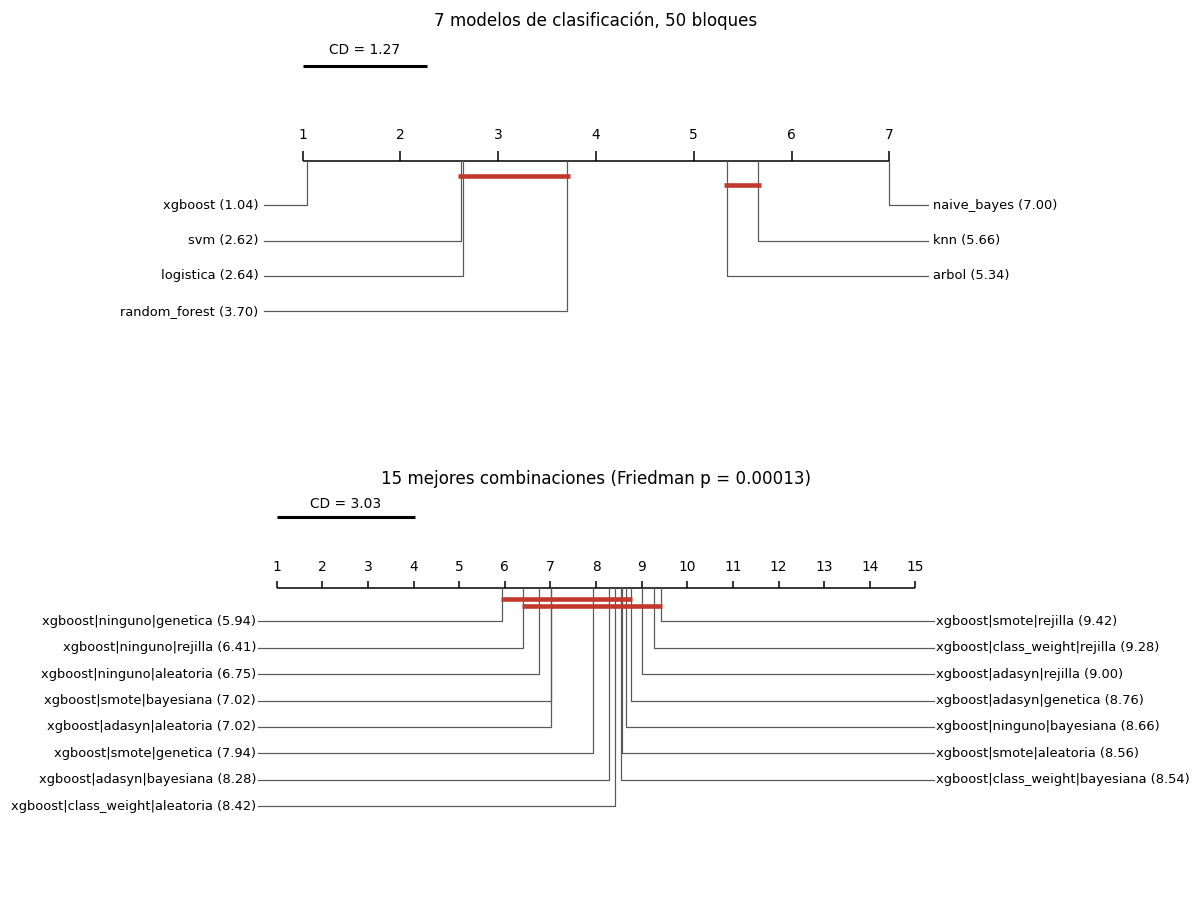

,xgboost,svm,logistica,random_forest,arbol,knn,naive_bayes
xgboost,1,0.00477,0.004,1.56e-08,0,0,0
svm,0.00477,1,1,0.159,6.42e-09,4.15e-11,0
logistica,0.004,1,1,0.177,8.65e-09,5.77e-11,0
random_forest,1.56e-08,0.159,0.177,1,0.00281,0.000116,4.63e-13
arbol,0,6.42e-09,8.65e-09,0.00281,1,0.99,0.00234
knn,0,4.15e-11,5.77e-11,0.000116,0.99,1,0.0317
naive_bayes,0,0,0,4.63e-13,0.00234,0.0317,1


In [7]:
fig, axes = plt.subplots(2, 1, figsize=(11, 8.5))
cd7 = est_.diferencia_critica(B_fam.shape[1], B_fam.shape[0])
est_.diagrama_cd(fr_fam["rangos_medios"], cd7, ax=axes[0],
                 titulo=f"7 modelos de clasificación, {B_fam.shape[0]} bloques")
top15 = B_clf.mean().sort_values(ascending=False).head(15).index
fr15 = est_.friedman(B_clf[top15])
cd15 = est_.diferencia_critica(15, B_clf.shape[0])
est_.diagrama_cd(fr15["rangos_medios"], cd15, ax=axes[1],
                 titulo=f"15 mejores combinaciones (Friedman p = {fr15['p']:.2g})")
fig.tight_layout()
graficos.guardar(fig, "09_cd_clasificacion")
plt.show()
nem = est_.nemenyi(B_fam)
display(nem.style.format("{:.3g}").background_gradient(cmap="RdYlGn", vmin=0, vmax=0.1))

### 3.3 Comparaciones dirigidas con DeLong (subconjunto reducido)

Se reservan para los **3 mejores modelos por AUC de validación cruzada** —los únicos cuya
ordenación relativa importa para elegir el modelo final— más la comparación del mejor con la
**línea base logística** del entregable anterior. DeLong compara AUC correlacionadas (mismas
observaciones de prueba). Cada comparación lleva su valor p crudo y ajustado (Holm y BH), el IC 95 %
bootstrap BCa de la diferencia de AUC (remuestreo estratificado por clase) y el delta de Cliff sobre
los AUC por bloque como tamaño del efecto.

In [8]:
top3 = [m for m in fc["modelo"] if m in FC][:3]
y_te = FC[top3[0]]["y"]
fuentes = {m: FC[m]["s"] for m in FC}
base = config.DIR_FINALES / "linea_base_e2.npz"
if base.is_file():
    z = np.load(base)
    assert np.array_equal(z["fila"], FC[top3[0]]["fila"])
    fuentes["linea_base_E2"] = z["s"]
pares = list(itertools.combinations(top3, 2))
if "linea_base_E2" in fuentes:
    pares.append((top3[0], "linea_base_E2"))

def dif_auc(y, a, b):
    return roc_auc_score(y, a) - roc_auc_score(y, b)

ruta = DIR_EST / "delong_clasificacion.csv"
if ruta.is_file():
    delong_df = pd.read_csv(ruta)
else:
    filas = []
    for a, b in pares:
        dl = est_.delong(y_te, fuentes[a], fuentes[b])
        bca = est_.bootstrap_bca(dif_auc, y_te, fuentes[a], fuentes[b], estratos=y_te, n_boot=N_BOOT)
        if a in B_fam and b in B_fam:
            cliff, mag = est_.delta_cliff(B_fam[a], B_fam[b])
        else:
            cliff, mag = np.nan, "-"
        filas.append({"Modelo A": a, "Modelo B": b, "AUC A": dl["auc_1"], "AUC B": dl["auc_2"],
                      "Diferencia de AUC": dl["diferencia"], "IC95 BCa inf": bca["ic_inf"],
                      "IC95 BCa sup": bca["ic_sup"], "z DeLong": dl["z"], "p crudo": dl["p"],
                      "delta de Cliff (bloques)": cliff, "magnitud": mag})
    delong_df = pd.DataFrame(filas)
    aj = est_.ajustar_p(delong_df["p crudo"])
    delong_df["p Holm"], delong_df["p BH"] = aj["p_holm"], aj["p_bh"]
    delong_df.to_csv(ruta, index=False)
display(delong_df.style.format(precision=4).hide(axis="index"))

Modelo A,Modelo B,AUC A,AUC B,Diferencia de AUC,IC95 BCa inf,IC95 BCa sup,z DeLong,p crudo,delta de Cliff (bloques),magnitud,p Holm,p BH
xgboost,svm,0.7754,0.7595,0.0159,0.0128,0.0189,10.1700,0.0000,0.5768,grande,0.0000,0.0000
xgboost,logistica,0.7754,0.7597,0.0156,0.0126,0.0186,9.9165,0.0000,0.5840,grande,0.0000,0.0000
svm,logistica,0.7595,0.7597,-0.0002,-0.0013,0.0008,-0.4716,0.6372,0.0072,insignificante,0.6372,0.6372
xgboost,linea_base_E2,0.7754,0.7603,0.0151,0.0119,0.0179,9.5611,0.0000,nan,-,0.0000,0.0000


### 3.4 Intervalos de confianza de las métricas (bootstrap BCa)

Para el AUC de cada modelo final en prueba. BCa corrige el sesgo y la asimetría de la distribución
bootstrap (el AUC está acotado en 1 y su distribución es asimétrica cerca del límite).

In [9]:
ruta = DIR_EST / "ic_metricas.csv"
if ruta.is_file():
    ic_df = pd.read_csv(ruta)
else:
    filas = []
    for m, d in FC.items():
        b = est_.bootstrap_bca(roc_auc_score, d["y"], d["s"], estratos=d["y"], n_boot=N_BOOT)
        dl = est_.delong_ic(d["y"], d["s"])
        filas.append({"tarea": "clasificacion", "Modelo": m, "Métrica": "AUC", "Estimación": b["estimacion"],
                      "IC95 inferior": b["ic_inf"], "IC95 superior": b["ic_sup"],
                      "IC95 DeLong": f"[{dl[0]:.4f}, {dl[1]:.4f}]"})
    rmse = lambda y, s: float(np.sqrt(np.mean((y - s) ** 2)))
    for m, d in FR.items():
        for nombre, f in (("RMSE", rmse), ("AUC", roc_auc_score)):
            b = est_.bootstrap_bca(f, d["y"].astype(float) if nombre == "RMSE" else d["y"], d["s"],
                                   estratos=d["y"], n_boot=N_BOOT)
            filas.append({"tarea": "regresion", "Modelo": m, "Métrica": nombre, "Estimación": b["estimacion"],
                          "IC95 inferior": b["ic_inf"], "IC95 superior": b["ic_sup"], "IC95 DeLong": "-"})
    ic_df = pd.DataFrame(filas)
    ic_df.to_csv(ruta, index=False)
display(ic_df.style.format(precision=4).hide(axis="index"))

tarea,Modelo,Métrica,Estimación,IC95 inferior,IC95 superior,IC95 DeLong
clasificacion,arbol,AUC,0.7017,0.6942,0.7091,"[0.6941, 0.7094]"
clasificacion,knn,AUC,0.6975,0.6902,0.7047,"[0.6899, 0.7052]"
clasificacion,logistica,AUC,0.7597,0.7529,0.7667,"[0.7528, 0.7666]"
clasificacion,naive_bayes,AUC,0.6477,0.6399,0.6557,"[0.6397, 0.6557]"
clasificacion,random_forest,AUC,0.7544,0.7470,0.7610,"[0.7475, 0.7614]"
clasificacion,svm,AUC,0.7595,0.7524,0.7663,"[0.7526, 0.7664]"
clasificacion,xgboost,AUC,0.7754,0.7685,0.7816,"[0.7686, 0.7821]"
regresion,arbol,RMSE,0.2661,0.2655,0.2668,-
regresion,arbol,AUC,0.7017,0.6942,0.7091,-
regresion,knn,RMSE,0.2668,0.2664,0.2672,-


**Lectura.** La secuencia conduce a una conclusión clara en la cabeza del ranking. Friedman rechaza
la igualdad entre las 112 combinaciones (χ² = 5,378, p ≈ 0) y entre los 7 modelos con su mejor
combinación (χ² = 280, p = 1.4·10⁻⁵⁷). El diagrama de diferencia crítica (CD = 1.27) separa cuatro
grupos: XGBoost solo en el primer lugar, con rango medio 1.04 (gana en casi todos los bloques); SVM,
logística y Random Forest, sin diferencias significativas entre sí según Nemenyi (p ≥ 0.16); árbol y
KNN, indistinguibles (p = 0.99), y Naive Bayes, último. Entre las 15 mejores combinaciones, todas de
XGBoost, Friedman detecta diferencias (p = 0.00013) pero el diagrama solo separa los extremos (rangos
5.94 y 9.42 con CD = 3.03): las variantes de balanceo y optimizador dentro de XGBoost son equivalentes
en la práctica.

En la prueba, DeLong confirma que XGBoost supera a SVM (+0.0159, IC 95 % BCa [0.0128, 0.0189]) y a la
logística (+0.0156, [0.0126, 0.0186]), con p de Holm < 0.0001 y efecto grande (delta de Cliff ≈ 0.58
sobre los bloques), mientras que SVM y logística no se distinguen (−0.0002, p = 0.64). Frente a la
línea base del entregable anterior, XGBoost gana +0.0151 de AUC con un intervalo [0.0119, 0.0179] que
excluye el cero. Los intervalos BCa de cada modelo (sección 3.4) coinciden con los de DeLong hasta la
tercera o cuarta cifra decimal, una comprobación cruzada de los dos métodos.

## 4. Regresión

### 4.1 Model Confidence Set sobre los 28 modelos

El MCS (Hansen, Lunde y Nason, 2011) parte de todo el universo y elimina iterativamente el peor modelo
mientras la hipótesis de igual capacidad predictiva se rechace, con bootstrap estacionario sobre las
pérdidas. El resultado es el conjunto de modelos estadísticamente indistinguibles del mejor con
confianza 1 − α (α = 0.10), sin necesidad de corregir por comparaciones múltiples. La pérdida es el
error cuadrático de las predicciones fuera de muestra sobre las 246 mil observaciones de desarrollo,
en el orden de `SK_ID_CURR`; para acotar el coste del bootstrap se promedian en bloques consecutivos de
25 observaciones (la pérdida media de cada modelo no cambia).

In [10]:
ruta = DIR_EST / "mcs_regresion.csv"
perdidas = {}
for c in combos_reg:
    o = ex.predicciones_oof("regresion", *c)
    perdidas[nombre_combo("regresion", *c)] = ((o["y"] - o["s"]) ** 2).to_numpy()
P = pd.DataFrame(perdidas)
if ruta.is_file():
    mcs = pd.read_csv(ruta, index_col=0)
else:
    mcs = est_.model_confidence_set(P, alfa=0.10, reps=200 if config.MODO_PRUEBA else 1000,
                                    agrupar=1 if config.MODO_PRUEBA else 25)
    B_perd = matriz_bloques("regresion", combos_reg, metrica="perdida")
    mcs["rango_promedio_bloques"] = est_.rangos(B_perd, mayor_es_mejor=False).mean().reindex(mcs.index)
    mcs.to_csv(ruta)
display(mcs.style.format(precision=4))
distintos = mcs["identico_a"].fillna("").astype(str) == ""
finalistas_mcs = mcs[mcs["en_conjunto"] & distintos].index.tolist()
print(f"En el conjunto de confianza: {int(mcs['en_conjunto'].sum())} modelos "
      f"({len(finalistas_mcs)} con predicciones distintas)")

,perdida_media,rango_perdida,p_mcs,identico_a,en_conjunto,rango_promedio_bloques
xgboost|rejilla,0.0674,1.0000,1.0000,nan,True,2.0600
xgboost|bayesiana,0.0674,2.0000,0.1890,nan,True,2.1200
xgboost|aleatoria,0.0674,3.0000,0.0040,nan,False,2.6200
xgboost|genetica,0.0675,4.0000,0.0000,nan,False,3.2000
random_forest|rejilla,0.0688,5.0000,0.0000,nan,False,6.9800
lasso|aleatoria,0.0691,6.0000,0.0000,nan,False,8.7700
lasso|rejilla,0.0691,7.0000,0.0000,nan,False,9.3600
lasso|bayesiana,0.0691,8.0000,0.0000,nan,False,9.3400
lasso|genetica,0.0691,9.0000,0.0000,nan,False,9.7100
random_forest|genetica,0.0691,10.0000,0.0000,nan,False,10.6600


En el conjunto de confianza: 2 modelos (2 con predicciones distintas)


### 4.2 Comparaciones dirigidas entre los finalistas: Giacomini-White y Clark-West

Se toman hasta 3 finalistas del MCS (los de menor pérdida).

* **Giacomini-White** (habilidad predictiva condicional) para los pares no anidados. Ningún par de
  algoritmos distintos está anidado: Ridge y Lasso usan penalizaciones distintas y ninguno es caso
  particular del otro con los hiperparámetros elegidos.
* **Clark-West** para la comparación anidada natural: cada finalista frente al **modelo restringido
  que predice la tasa base** (solo intercepto), que es un caso particular de cualquier regresor. Es la
  prueba de que el modelo aporta capacidad predictiva real, con la corrección del sesgo que el DM tiene
  a favor del modelo grande en comparaciones anidadas.

In [11]:
fin3 = finalistas_mcs[:3]
ref = ex.predicciones_oof("regresion", *combos_reg[0])
y_dev = ref["y"].to_numpy().astype(float)
# benchmark restringido: la tasa de incumplimiento del entrenamiento de cada pliegue externo
bench = np.empty(len(ref))
for k in range(config.N_EXTERNOS):
    m = ref["pliegue"].to_numpy() == k
    bench[m] = y_dev[~m].mean()
pred = {n: ex.predicciones_oof("regresion", *[c for c in combos_reg if nombre_combo("regresion", *c) == n][0])["s"].to_numpy()
        for n in fin3}
filas = []
for a, b in itertools.combinations(fin3, 2):
    gw = est_.giacomini_white(P[a], P[b])
    d, mag = est_.d_cohen_pareado(P[a] - P[b])
    filas.append({"prueba": "Giacomini-White", "A": a, "B": b, "estadístico": gw["estadistico"],
                  "p": gw["p"], "mejor": b if gw["media_dif_perdida"] > 0 else a,
                  "d de Cohen": d, "magnitud": mag})
for a in fin3:
    cw = est_.clark_west(y_dev, bench, pred[a])
    filas.append({"prueba": "Clark-West", "A": "tasa base (restringido)", "B": a, "estadístico": cw["t"],
                  "p": cw["p_unilateral"], "mejor": a if cw["p_unilateral"] < 0.05 else "-",
                  "d de Cohen": np.nan, "magnitud": "-"})
dirigidas = pd.DataFrame(filas)
if len(dirigidas):
    aj = est_.ajustar_p(dirigidas["p"])
    dirigidas["p Holm"], dirigidas["p BH"] = aj["p_holm"], aj["p_bh"]
dirigidas.to_csv(DIR_EST / "gw_cw_regresion.csv", index=False)
display(dirigidas.style.format(precision=4, na_rep="-").hide(axis="index"))

prueba,A,B,estadístico,p,mejor,d de Cohen,magnitud,p Holm,p BH
Giacomini-White,xgboost|rejilla,xgboost|bayesiana,1.4212,0.4913,xgboost|rejilla,-0.0024,insignificante,0.4913,0.4913
Clark-West,tasa base (restringido),xgboost|rejilla,90.7032,0.0000,xgboost|rejilla,-,-,0.0000,0.0000
Clark-West,tasa base (restringido),xgboost|bayesiana,91.7234,0.0000,xgboost|bayesiana,-,-,0.0000,0.0000


### 4.3 Confirmación puntual: Diebold-Mariano con corrección HLN (Cuadro 7)

Sobre la **prueba final**, entre los tres mejores regresores finales (por AUC de validación cruzada):
diferencia de pérdida cuadrática media, estadístico DM con la corrección de Harvey-Leybourne-Newbold,
IC 95 % por bootstrap estacionario (Politis-Romano, longitud de bloque óptima de Politis-White) y
valores p ajustados. Pérdidas en el orden de `SK_ID_CURR`.

In [12]:
top3r = [m for m in fr["modelo"] if m in FR][:3]
filas = []
for a, b in itertools.combinations(top3r, 2):
    oa, ob = np.argsort(FR[a]["fila"]), np.argsort(FR[b]["fila"])
    y = FR[a]["y"][oa].astype(float)
    ea, eb = y - FR[a]["s"][oa], y - FR[b]["s"][ob]
    dm = est_.diebold_mariano(ea, eb)
    ic = est_.ic_bootstrap_estacionario(ea ** 2 - eb ** 2, reps=200 if config.MODO_PRUEBA else 1000)
    d, mag = est_.d_cohen_pareado(ea ** 2 - eb ** 2)
    filas.append({"Modelo A": a, "Modelo B": b, "Diferencia de pérdida (A−B)": dm["media_dif_perdida"],
                  "IC95 inf": ic["ic_inf"], "IC95 sup": ic["ic_sup"], "DM-HLN": dm["dm_hln"],
                  "p crudo": dm["p"], "d de Cohen": d, "magnitud": mag,
                  "bloque medio": ic["bloque_medio"]})
dm_df = pd.DataFrame(filas)
if len(dm_df):
    aj = est_.ajustar_p(dm_df["p crudo"])
    dm_df["p Holm"], dm_df["p BH"] = aj["p_holm"], aj["p_bh"]
dm_df.to_csv(DIR_EST / "diebold_mariano.csv", index=False)
display(dm_df.style.format(precision=5).hide(axis="index"))

Modelo A,Modelo B,Diferencia de pérdida (A−B),IC95 inf,IC95 sup,DM-HLN,p crudo,d de Cohen,magnitud,bloque medio,p Holm,p BH
xgboost,lasso,-0.00203,-0.00236,-0.00173,-13.27338,0.00000,-0.05352,insignificante,1.00000,0.00000,0.00000
xgboost,ridge,-0.00207,-0.00240,-0.00176,-13.72838,0.00000,-0.05536,insignificante,1.00000,0.00000,0.00000
lasso,ridge,-0.00004,-0.00006,-0.00002,-3.09203,0.00199,-0.01247,insignificante,1.99476,0.00199,0.00199


**Lectura.** De los 28 regresores, el MCS con α = 0.10 conserva solo dos: XGBoost con rejilla y con
optimización bayesiana (pérdida media 0.0674 ambos). XGBoost con búsqueda aleatoria y con genética
quedan fuera por poco (p del MCS 0.004 y < 0.001), y el resto a gran distancia. Clark-West confirma
que los dos finalistas superan con claridad al modelo restringido que predice la tasa base del
pliegue (estadísticos 90.7 y 91.7, p ≈ 0), y Giacomini-White no los distingue entre sí (p = 0.49, d de
Cohen −0.002): son el mismo algoritmo con hiperparámetros parecidos.

El Diebold-Mariano con corrección HLN sobre la prueba confirma al mejor regresor frente al segundo y
al tercero: XGBoost reduce la pérdida cuadrática respecto de Lasso en 0.0020 (IC 95 % [0.0017,
0.0024] a favor de XGBoost) y respecto de Ridge en 0.0021, con p < 0.0001; el intervalo excluye el
cero. El tamaño del efecto por observación, sin embargo, es insignificante (d de Cohen −0.05): la
ventaja de XGBoost es real y sistemática, pero pequeña en cada predicción individual, como
corresponde a un objetivo binario en el que la pérdida de cada observación está dominada por el
azar del evento. Lasso y Ridge también difieren (p = 0.002), por apenas 0.00004.

### 4.4 Control de *data snooping*: SPA de Hansen y Reality Check de White

El MCS y las pruebas dirigidas comparan modelos entre sí. La Sección 6.3 de la guía plantea además
otra pregunta: ¿**algún** modelo del conjunto supera de verdad a una referencia sencilla, o la
aparente superioridad del ganador es producto de haber probado 28 modelos? Se toma como referencia el
mejor modelo lineal (Ridge o Lasso, el de menor pérdida media), que es el análogo en regresión de la
línea base logística, y se comparan contra él los otros 27 modelos con las mismas pérdidas fuera de
muestra del MCS (bloques de 25 observaciones y bootstrap estacionario):

* **Reality Check de White (2000)**: toma la mayor de las diferencias medias de pérdida frente a la
  referencia, sin estudentizar, y obtiene su distribución nula por bootstrap suponiendo que todos los
  modelos son tan buenos como la referencia. Eso lo vuelve conservador cuando hay modelos claramente
  peores en el conjunto.
* **SPA de Hansen (2005)**: estudentiza las diferencias y solo recentra los modelos que no son
  claramente peores, lo que corrige ese sesgo conservador. Se reportan sus tres valores p (inferior,
  consistente y superior); el **consistente** es el de referencia.
* **StepM de Romano y Wolf (2005)**: identifica *cuáles* modelos superan a la referencia, controlando
  el error familiar (α = 0.05).

Un valor p pequeño indica que al menos un modelo supera a la referencia aun después de controlar por
el número de modelos probados.

In [13]:
ruta = DIR_EST / "spa_regresion.json"
lineales = [c for c in P.columns if c.split("|")[0] in ("ridge", "lasso")]
referencia = min(lineales, key=lambda c: P[c].mean())
spa = json.loads(ruta.read_text(encoding="utf-8")) if ruta.is_file() else None
if spa is None or spa.get("referencia") != referencia:
    spa = est_.spa_reality_check(P, referencia, alfa=0.05,
                                 reps=200 if config.MODO_PRUEBA else 1000,
                                 agrupar=1 if config.MODO_PRUEBA else 25)
    ruta.write_text(json.dumps(spa, indent=1), encoding="utf-8")
print(f"Referencia: {referencia} (pérdida media {P[referencia].mean():.5f}) | modelos comparados: {spa['modelos']}")
display(pd.DataFrame([
    {"Prueba": "SPA de Hansen, valor p consistente", "valor p": spa["p_spa_consistente"]},
    {"Prueba": "SPA de Hansen, valor p inferior", "valor p": spa["p_spa_inferior"]},
    {"Prueba": "SPA de Hansen, valor p superior", "valor p": spa["p_spa_superior"]},
    {"Prueba": "Reality Check de White", "valor p": spa["p_reality_check"]},
]).style.format({"valor p": "{:.4f}"}).hide(axis="index"))
sup = spa["superiores_stepm"]
print(f"StepM (Romano-Wolf, α = 0.05): {len(sup)} de {spa['modelos']} modelos superan a la referencia")
if sup:
    display(pd.DataFrame({"modelo": sup, "perdida_media": [P[c].mean() for c in sup],
                          "mejora_frente_a_referencia": [P[referencia].mean() - P[c].mean() for c in sup]})
            .sort_values("perdida_media").style.format(precision=5).hide(axis="index"))

Referencia: lasso|aleatoria (pérdida media 0.06908) | modelos comparados: 27


Prueba,valor p
"SPA de Hansen, valor p consistente",0.0000
"SPA de Hansen, valor p inferior",0.0000
"SPA de Hansen, valor p superior",0.0000
Reality Check de White,0.0000


StepM (Romano-Wolf, α = 0.05): 5 de 27 modelos superan a la referencia


modelo,perdida_media,mejora_frente_a_referencia
xgboost|rejilla,0.06736,0.00173
xgboost|bayesiana,0.06738,0.00170
xgboost|aleatoria,0.06743,0.00165
xgboost|genetica,0.06749,0.00159
random_forest|rejilla,0.06883,0.00025


**Lectura.** La referencia es Lasso con búsqueda aleatoria, el modelo lineal de menor pérdida
media (0.06908). Las cuatro pruebas rechazan con claridad (valores p < 0.001 con 1,000 réplicas): al
menos un modelo la supera aun después de controlar por haber probado 27 alternativas, y como el
Reality Check, el más conservador, también rechaza, la conclusión no depende de cómo se recentre la
distribución nula. El StepM identifica cuáles: los cuatro XGBoost (con una reducción de la pérdida
cuadrática media de 0.0016 a 0.0017 frente a Lasso) y, por un margen diez veces menor (0.00025),
Random Forest con rejilla. Ningún otro modelo supera al lineal. La superioridad de XGBoost que
mostraron el MCS y el Diebold-Mariano no es, por tanto, un artefacto del data snooping: es la única
familia que mejora de forma genuina al modelo lineal en regresión.

## 5. Evaluación general: los 14 algoritmos en la misma métrica

Todos los modelos se entrenaron sobre `TARGET` y se evalúan con AUC-ROC, de modo que clasificadores y
regresores entran en un mismo ranking. Se aplica la misma secuencia: Friedman y diagrama CD sobre los
50 bloques con la mejor combinación de cada algoritmo, y DeLong entre el mejor clasificador y el mejor
regresor en la prueba.

Friedman 14 algoritmos: chi2 = 606.28, p = 3.52e-121


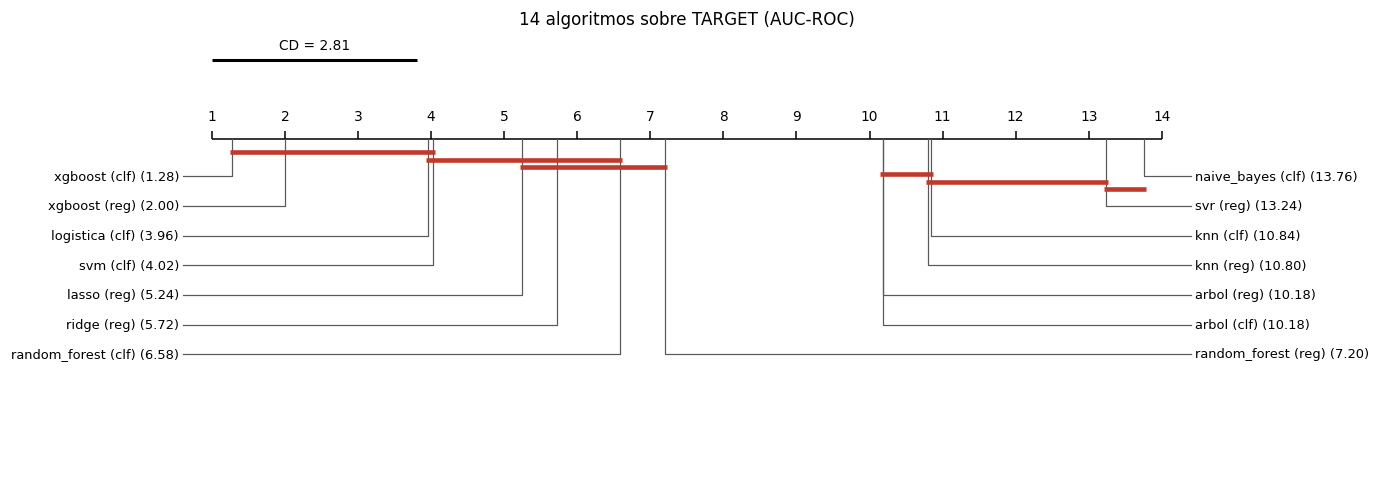

tarea,modelo,AUC prueba,AUC CV,AUC CV sd
clasificacion,xgboost,0.7754,0.7721,0.0038
regresion,xgboost,0.7737,0.7695,0.0032
regresion,lasso,0.7604,0.7554,0.0026
clasificacion,logistica,0.7597,0.7576,0.0028
clasificacion,svm,0.7595,0.7578,0.0031
regresion,ridge,0.7594,0.7549,0.0026
regresion,random_forest,0.7546,0.7476,0.0035
clasificacion,random_forest,0.7544,0.7497,0.0035
clasificacion,arbol,0.7017,0.6965,0.0060
regresion,arbol,0.7017,0.6965,0.0060


DeLong mejor clasificador (xgboost) vs mejor regresor (xgboost): ΔAUC = +0.0017, IC95 [-0.0001, +0.0034], p = 0.0579
  arbol          clasificador vs regresor: ΔAUC = +0.0000, p = 1
  knn            clasificador vs regresor: ΔAUC = +0.0000, p = 1
  xgboost        clasificador vs regresor: ΔAUC = +0.0017, p = 0.0579
  random_forest  clasificador vs regresor: ΔAUC = -0.0002, p = 0.848


In [14]:
fam_reg = [tuple(r) for r in fr[["modelo", "balanceo", "optimizador"]].to_numpy()]
B_fam_r = B_reg[[nombre_combo("regresion", *c) for c in fam_reg]]
B_fam_r.columns = [f"{c[0]} (reg)" for c in fam_reg]
B14 = pd.concat([B_fam.add_suffix(" (clf)"), B_fam_r], axis=1)
fr14 = est_.friedman(B14)
cd14 = est_.diferencia_critica(B14.shape[1], B14.shape[0])
print(f"Friedman 14 algoritmos: chi2 = {fr14['chi2']:.2f}, p = {fr14['p']:.3g}")
fig, ax = plt.subplots(figsize=(12, 5.2))
est_.diagrama_cd(fr14["rangos_medios"], cd14, ax=ax, titulo="14 algoritmos sobre TARGET (AUC-ROC)")
graficos.guardar(fig, "09_cd_general")
plt.show()

filas = []
for tarea, F in (("clasificacion", FC), ("regresion", FR)):
    for m, d in F.items():
        filas.append({"tarea": tarea, "modelo": m, "AUC prueba": d["registro"]["metricas"]["auc_roc"],
                      "AUC CV": d["registro"]["auc_cv_media"], "AUC CV sd": d["registro"]["auc_cv_sd"]})
general = pd.DataFrame(filas).sort_values("AUC prueba", ascending=False)
general.to_csv(config.DIR_RESULTADOS / "ranking_general.csv", index=False)
display(general.style.format(precision=4).hide(axis="index"))

mc, mr = fc.iloc[0]["modelo"], fr.iloc[0]["modelo"]
if mc in FC and mr in FR:
    assert np.array_equal(FC[mc]["fila"], FR[mr]["fila"])
    dl = est_.delong(FC[mc]["y"], FC[mc]["s"], FR[mr]["s"])
    print(f"DeLong mejor clasificador ({mc}) vs mejor regresor ({mr}): "
          f"ΔAUC = {dl['diferencia']:+.4f}, IC95 [{dl['ic95'][0]:+.4f}, {dl['ic95'][1]:+.4f}], p = {dl['p']:.3g}")
    for m in set(FC) & {x.replace(" (reg)", "") for x in B_fam_r.columns}:
        if m in FR:
            dl = est_.delong(FC[m]["y"], FC[m]["s"], FR[m]["s"])
            print(f"  {m:14s} clasificador vs regresor: ΔAUC = {dl['diferencia']:+.4f}, p = {dl['p']:.3g}")

**Lectura.** Medidos con la misma métrica sobre el mismo objetivo, los regresores flexibles igualan
a sus contrapartes de clasificación, como predecía el capítulo 03. El árbol y KNN dan exactamente el
mismo AUC en la prueba como clasificador y como regresor (0.7017 y 0.6975; DeLong p = 1), y Random
Forest es indistinguible (−0.0002, p = 0.85). En XGBoost el clasificador supera al regresor por
0.0017 (IC 95 % [−0.0001, 0.0034], p = 0.058): la log-verosimilitud se adapta algo mejor a un
objetivo binario que el error cuadrático, pero la diferencia queda en el límite de la significación.
Entre los lineales, Lasso (0.7604) iguala en la prueba a la logística (0.7597), aunque en validación
cruzada quedaba 0.002 por debajo. SVR es el único que se aparta: con pérdida ε-insensible aprende algo
parecido a una mediana condicional y queda penúltimo en el ranking conjunto (rango medio 13.24 de 14),
por delante solo de Naive Bayes.

En ese ranking (Friedman χ² = 606, p ≈ 10⁻¹²¹; CD = 2.81) los dos XGBoost encabezan con rangos 1.28 y
2.00. Con 14 algoritmos y 50 bloques, Nemenyi no alcanza a separarlos de la logística y de SVM (3.96 y
4.02): es una muestra de lo conservadora que es esa prueba con muchos algoritmos, porque DeLong sobre
la prueba sí establece la diferencia (sección 3.3).